In [239]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pulp import *

In [240]:
data=pd.read_csv('confiserie.csv',header=None)
x=data[1]
y=data[2]

In [241]:
model = LpProblem(name="Ex1", sense=LpMinimize) 

In [242]:
n=len(data)

In [243]:
z = LpVariable.matrix("z", list(range(1,n+1)),lowBound=0)
a = pulp.LpVariable("a",  lowBound=0)
b = pulp.LpVariable("b",  lowBound=0)
model += lpSum(z)

In [244]:
for i in range(n):
    model+=z[i]>=y[i]-a-b*x[i]
    model+=z[i]>=-(y[i]-a-b*x[i])

In [245]:
status = model.solve(solver=GLPK(msg=True,keepFiles=True))
print("Status:", LpStatus[model.status])
print("objective=", value(model.objective))

GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --cpxlp Ex1-pulp.lp -o Ex1-pulp.sol
Reading problem data from 'Ex1-pulp.lp'...
34 rows, 19 columns, 102 non-zeros
40 lines were read
GLPK Simplex Optimizer, v4.65
34 rows, 19 columns, 102 non-zeros
Preprocessing...
34 rows, 19 columns, 102 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  2.527e+02  ratio =  2.527e+02
GM: min|aij| =  3.431e-01  max|aij| =  2.915e+00  ratio =  8.497e+00
EQ: min|aij| =  1.177e-01  max|aij| =  1.000e+00  ratio =  8.497e+00
Constructing initial basis...
Size of triangular part is 34
      0: obj =   0.000000000e+00 inf =   5.525e+03 (17)
     29: obj =   4.398734866e+03 inf =   3.441e-14 (0)
*    33: obj =   4.271542135e+03 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs
Memory used: 0.1 Mb (68353 bytes)
Writing basic solution to 'Ex1-pulp.sol'...
Status: Optimal
objective= 4271.5427199999995


In [246]:
for i in range(0,n):
	print("z[",i,"]=",value(y[i]))

z[ 0 ]= 327.4
z[ 1 ]= 179.5
z[ 2 ]= 279.4
z[ 3 ]= 139.1
z[ 4 ]= 92.5
z[ 5 ]= 926.7
z[ 6 ]= 2186.3
z[ 7 ]= 96.8
z[ 8 ]= 523.9
z[ 9 ]= 935.9
z[ 10 ]= 444.2
z[ 11 ]= 119.7
z[ 12 ]= 300.7
z[ 13 ]= 201.9
z[ 14 ]= 194.7
z[ 15 ]= 1592.9
z[ 16 ]= 5142.2


In [247]:
print(value(a)),print(value(b))

25.9376
20.2464


(None, None)

In [248]:
a1,b1=25.9376,20.2464

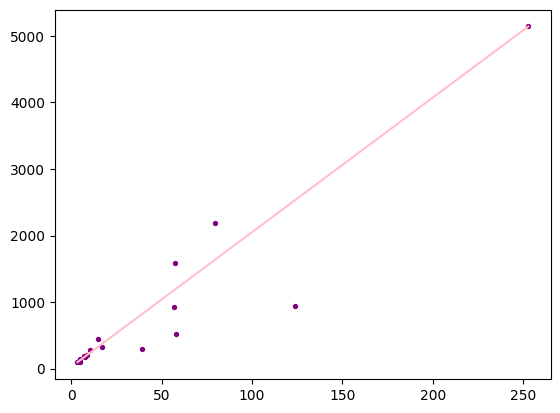

In [249]:
plt.scatter(x,y,s=8,c="purple")
plt.plot([min(x),max(x)],[a1+b1*min(x),a1+b1*max(x)],c="pink")

In [250]:
#1.2    La droite de régression obtenue est plus précise que celle du TME précédent.

In [251]:
x_cp=x
x_cp[16]=5.27

/tmp/ipykernel_174511/2678172851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_cp[16]=5.27


In [252]:
b=np.sum((x_cp-np.mean(x_cp))* (y-np.mean(y)))/len(x_cp)/np.var(x_cp)
a=np.mean(y)-b*np.mean(x_cp)

In [253]:
z2 = LpVariable.matrix("z2", list(range(1,n+1)),lowBound=0)
a2 = pulp.LpVariable("a2",  lowBound=0)
b2 = pulp.LpVariable("b2",  lowBound=0)
model += lpSum(z2)
for i in range(n):
    model+=z2[i]>=y[i]-a2-b2*x_cp[i]
    model+=z2[i]>=-(y[i]-a2-b2*x_cp[i])
status = model.solve(solver=GLPK(msg=True,keepFiles=True))
print("Status:", LpStatus[model.status])
print("objective=", value(model.objective))
print(value(a2)),print(value(b2))

GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --cpxlp Ex1-pulp.lp -o Ex1-pulp.sol
Reading problem data from 'Ex1-pulp.lp'...
68 rows, 38 columns, 204 non-zeros
74 lines were read
GLPK Simplex Optimizer, v4.65
68 rows, 38 columns, 204 non-zeros
Preprocessing...
68 rows, 38 columns, 204 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  2.527e+02  ratio =  2.527e+02
GM: min|aij| =  3.431e-01  max|aij| =  2.915e+00  ratio =  8.497e+00
EQ: min|aij| =  1.177e-01  max|aij| =  1.000e+00  ratio =  8.497e+00
Constructing initial basis...
Size of triangular part is 68
      0: obj =   0.000000000e+00 inf =   1.473e+04 (34)
     57: obj =   9.866566000e+03 inf =   4.862e-14 (0)
*    60: obj =   8.663818023e+03 inf =   3.441e-14 (0)
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs
Memory used: 0.1 Mb (123295 bytes)
Writing basic solution to 'Ex1-pulp.sol'...
Status: Optimal
objective= 8663.814480000001
74.9407
14.593


/usr/local/lib/python3.9/site-packages/pulp/pulp.py:1704: UserWarning: Overwriting previously set objective.
  warnings.warn("Overwriting previously set objective.")


(None, None)

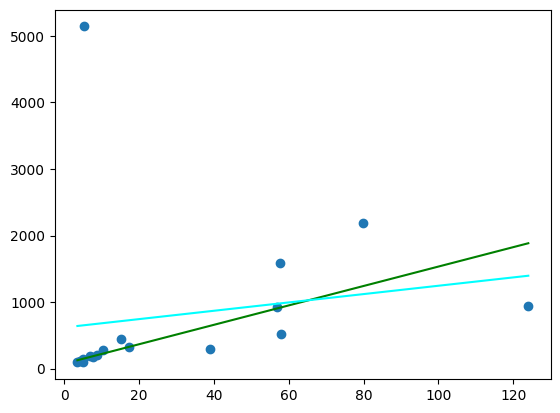

In [254]:
a2,b2=74.9407,14.593
plt.scatter(x_cp,y)
plt.plot([min(x_cp),max(x_cp)],[a2+b2*min(x_cp),a2+b2*max(x_cp)],c="green")
plt.plot([min(x_cp),max(x_cp)],[a+b*min(x_cp),a+b*max(x_cp)],c="aqua")

In [255]:
#1.3 On constate que la droite de régression basée sur les 
#moindres carrées est plus sensible aux données aberrantes.

In [256]:
d=pd.read_csv('ozoneApprentissage.csv',header=None)
d

,0,1,2,3,4
0,3,6,2,8,3
1,7,7,11,14,15
2,11,11,23,33,19
3,15,12,26,34,27
4,21,16,12,5,23
5,23,17,16,10,23
6,28,22,22,15,31
7,31,16,28,24,39
8,38,21,34,31,47
9,39,27,27,8,51


In [257]:
model0 = LpProblem(name="EX2", sense=LpMinimize)
n0=len(d)
x1=d[0]
x2=d[1]
x3=d[2]
x4=d[3]
y0=d[4]
z0 = LpVariable.matrix("z0", list(range(1,n+1)),lowBound=0)

In [258]:
model0 += lpSum(z0) 

In [259]:
b0 = LpVariable("b0",  lowBound=0) 
b1 = LpVariable("b1",  lowBound=0) 
b2 = LpVariable("b2",  lowBound=0) 
b3 = LpVariable("b3",  lowBound=0) 
b4 = LpVariable("b4",  lowBound=0) 

for i in range(n):
    model0 +=  z0[i]>=y0[i]-b0-x1[i]*b1-x2[i]*b2-x3[i]*b3-x4[i]*b4
    model0 +=  z0[i]>=-(y0[i]-b0-x1[i]*b1-x2[i]*b2-x3[i]*b3-x4[i]*b4)

In [260]:
status = model0.solve(solver=GLPK(msg=True,keepFiles=True))
print("Status:", LpStatus[model0.status])
print("objective=", value(model0.objective))

GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --cpxlp EX2-pulp.lp -o EX2-pulp.sol
Reading problem data from 'EX2-pulp.lp'...
34 rows, 22 columns, 204 non-zeros
40 lines were read
GLPK Simplex Optimizer, v4.65
34 rows, 22 columns, 204 non-zeros
Preprocessing...
34 rows, 22 columns, 204 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  9.500e+01  ratio =  9.500e+01
GM: min|aij| =  4.196e-01  max|aij| =  2.383e+00  ratio =  5.679e+00
EQ: min|aij| =  1.777e-01  max|aij| =  1.000e+00  ratio =  5.627e+00
Constructing initial basis...
Size of triangular part is 34
      0: obj =   0.000000000e+00 inf =   4.389e+02 (17)
     29: obj =   1.006847826e+02 inf =   3.553e-15 (0)
*    38: obj =   6.723076923e+01 inf =   3.055e-15 (0)
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs
Memory used: 0.1 Mb (95331 bytes)
Writing basic solution to 'EX2-pulp.sol'...
Status: Optimal
objective= 67.23075600000001
